Total de 70734 registros prontos para o modelo (preço por m²).

--- Importância Agrupada (Alvo: Preço por m²) ---
area             0.461935
bedrooms         0.198986
baths            0.173401
city             0.121365
property_type    0.044313
dtype: float64
-------------------------------------------------

Exibindo novo gráfico de importância agrupada (Preço por m²).


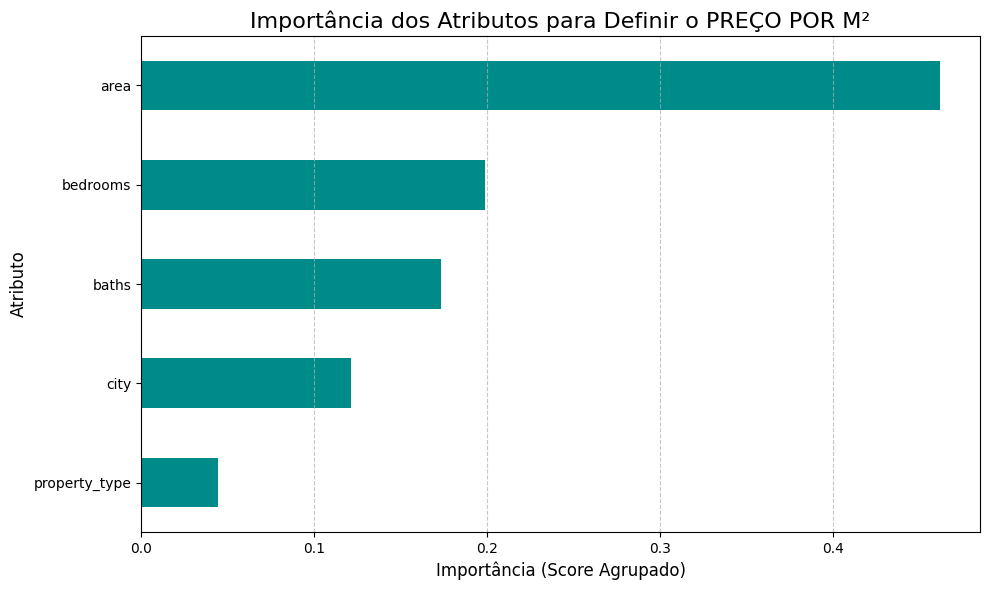

In [1]:
# Configura o Matplotlib para exibir gráficos inline no Jupyter
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Define o nome do arquivo
file_name = "pakistan_house_prices.csv"

try:
    df = pd.read_csv(file_name)
    clean_df = df.copy()
    
    if 'Unnamed: 0' in clean_df.columns:
        clean_df.drop(columns=['Unnamed: 0'], inplace=True)
        
    clean_df = clean_df[clean_df['Area_in_Marla'] != 0]
    clean_df = clean_df[clean_df['bedrooms'] != 0]

    clean_df['price'] = df['price'] / 52 
    clean_df['price'] = clean_df['price'].round(2)


    # Converter de Marla pra metro quadrado
    clean_df['area'] = clean_df['Area_in_Marla'] * 25.292852 
    clean_df['area'] = clean_df['area'].round(0).astype(int) 
    clean_df.drop(columns=['Area_in_Marla'], inplace=True)

    # Preparação Adicional para Machine Learning (ML)
    clean_df['price'] = pd.to_numeric(clean_df['price'], errors='coerce')
    ml_df = clean_df[clean_df['purpose'] == 'For Sale'].copy()
    ml_df = ml_df.dropna(subset=['price', 'property_type', 'city', 'baths', 'bedrooms', 'area'])
    ml_df = ml_df.drop(columns=['location', 'purpose'])
    
    
    # Criar a coluna 'preço por metro quadrado'
    ml_df['price_per_m2'] = ml_df['price'] / ml_df['area']
    
    if ml_df.empty:
        print("\n!!! ATENÇÃO: Após a limpeza, nenhum dado restou para o treinamento. !!!")
    else:
        print(f"Total de {len(ml_df)} registros prontos para o modelo (preço por m²).")
        
        # O 'alvo' (target) agora é o 'price_per_m2'
        y = ml_df['price_per_m2']
        
        # As 'features' (atributos) são os dados que usamos para prever
        # Note que 'area' CONTINUA sendo uma feature! (ex: áreas maiores podem ter um $/m² menor)
        # Removemos 'price' E 'price_per_m2' das features.
        X = ml_df.drop(['price', 'price_per_m2'], axis=1)
        
        # Definir Listas de Features (Sem alteração)
        numeric_features = ['baths', 'bedrooms', 'area']
        categorical_features = ['property_type', 'city']

        # Criar Pipeline de ML (Sem alteração)
        preprocessor = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
            ],
            remainder='passthrough'
        )

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
        ])

        # Treinar o Modelo (com o novo 'y')
        pipeline.fit(X, y)

    
        # Extrair e Agrupar Importâncias (Lógica idêntica)
        # Nomes das colunas categóricas transformadas
        encoded_cat_features = pipeline.named_steps['preprocessor'] \
                                       .named_transformers_['cat'] \
                                       .get_feature_names_out(categorical_features)
        
        # Nomes das colunas numéricas
        numeric_features_out = numeric_features
        
        # Combinar todos os nomes
        all_feature_names = np.concatenate([encoded_cat_features, numeric_features_out])

        # Obter os scores de importância
        importances = pipeline.named_steps['regressor'].feature_importances_

        # Criar um DataFrame
        feature_importance_df = pd.DataFrame({
            'Feature': all_feature_names,
            'Importance': importances
        })
        
        # Agrupar importâncias
        grouped_importances = {}
        for cat_feature in categorical_features: # ['property_type', 'city']
            related_features = [f for f in encoded_cat_features if f.startswith(f"{cat_feature}_")]
            total_importance = feature_importance_df[feature_importance_df['Feature'].isin(related_features)]['Importance'].sum()
            grouped_importances[cat_feature] = total_importance

        for num_feature in numeric_features: # ['baths', 'bedrooms', 'area']
            total_importance = feature_importance_df[feature_importance_df['Feature'] == num_feature]['Importance'].sum()
            grouped_importances[num_feature] = total_importance
            
        # Converter para Série
        grouped_importance_series = pd.Series(grouped_importances).sort_values(ascending=False)

        print("\n--- Importância Agrupada (Alvo: Preço por m²) ---")
        print(grouped_importance_series)
        print("-------------------------------------------------\n")

        # Plotar os Atributos Agrupados     
        plt.figure(figsize=(10, 6))
        grouped_importance_series.sort_values(ascending=True).plot(kind='barh', color='darkcyan') # Mudei a cor
        
        plt.xlabel("Importância (Score Agrupado)", fontsize=12)
        plt.ylabel("Atributo", fontsize=12)
        
        # Novo título
        plt.title("Importância dos Atributos para Definir o PREÇO POR M²", fontsize=16)
        
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        
        print("Exibindo novo gráfico de importância agrupada (Preço por m²).")
        plt.show()

except FileNotFoundError:
    print(f"Erro: O arquivo '{file_name}' não foi encontrado.")
except KeyError as e:
    print(f"Erro: Coluna não encontrada: {e}. Verifique se as colunas (ex: 'Area_in_Marla', 'bedrooms') existem no seu CSV.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

In [2]:
ml_df.head()

,property_type,price,city,baths,bedrooms,area,price_per_m2
0,Flat,192307.69,Islamabad,2,2,101,1904.036535
1,Flat,132692.31,Islamabad,3,3,142,934.452887
2,House,317307.69,Islamabad,6,5,202,1570.830149
3,House,836538.46,Islamabad,4,4,1012,826.619032
4,House,134615.38,Islamabad,3,3,202,666.412772
